Epoch [10/80], Loss: 0.0975
Epoch [20/80], Loss: 0.0784
Epoch [30/80], Loss: 0.0611
Epoch [40/80], Loss: 0.0458
Epoch [50/80], Loss: 0.0349
Epoch [60/80], Loss: 0.0283
Epoch [70/80], Loss: 0.0185
Epoch [80/80], Loss: 0.0088

Root Mean Squared Error (RMSE): 7.9367
Mean Absolute Error (MAE): 6.1228
R-squared Score (R²): 0.8984

Final Portfolio Value: $1718.14
Total Profit: $718.14
Return on Investment (ROI): 71.81%


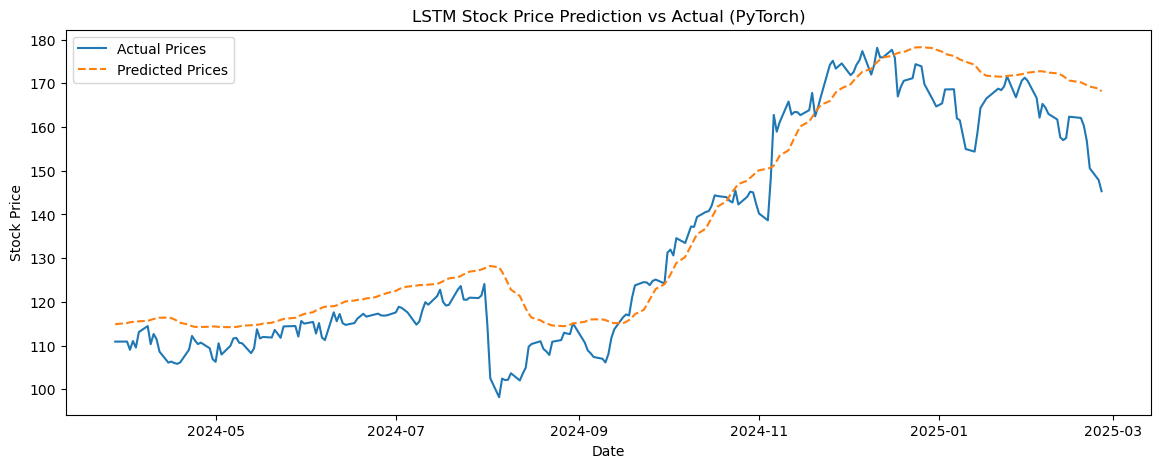

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"APO.csv")  # Use raw string or double backslashes

# Convert Date column to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# Selecting relevant features
features = ['Close_Prices', 'Open_Prices', 'High_Prices', 'Low_Prices', 'Volume']

# Split into training (till 2023) and testing (2024 onward)
train_data = df[df['Date'] < '2024-01-01']
test_data = df[df['Date'] >= '2024-01-01']

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data[features])
test_scaled = scaler.transform(test_data[features])

# Function to create sequences
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length][0])  # Predicting Close_Prices
    return np.array(sequences), np.array(labels)

SEQ_LENGTH = 60  # Using past 60 days to predict next day
X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)  # Fix shape issue

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

# Define Improved LSTM Model
class StockLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, num_layers=2, output_size=1):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

# Initialize Model
model = StockLSTM()

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Train the Model
EPOCHS = 80  # More training for better learning
BATCH_SIZE = 16

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}")

# Make Predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

# Convert predictions and actual values back to original scale (Fix Scaling Issue)
predictions = scaler.inverse_transform(
    np.concatenate([predictions, np.zeros((predictions.shape[0], 4))], axis=1)
)[:, 0]

actual_prices = scaler.inverse_transform(
    np.concatenate([y_test.numpy(), np.zeros((y_test.shape[0], 4))], axis=1)
)[:, 0]

# Evaluate Model Performance
rmse = np.sqrt(mean_squared_error(actual_prices, predictions))
mae = mean_absolute_error(actual_prices, predictions)
r2 = r2_score(actual_prices, predictions)

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

# Simulate Trading Strategy with $1000 Initial Capital
initial_capital = 1000
capital = initial_capital
shares = 0  # Number of shares held

for i in range(len(predictions) - 1):  
    predicted_price_today = predictions[i]
    predicted_price_next_day = predictions[i + 1]

    if predicted_price_next_day > predicted_price_today:
        # Buy as many shares as possible
        shares_to_buy = capital // predicted_price_today
        capital -= shares_to_buy * predicted_price_today
        shares += shares_to_buy
    elif predicted_price_next_day < predicted_price_today and shares > 0:
        # Sell all shares
        capital += shares * predicted_price_today
        shares = 0

# Final Portfolio Value
final_value = capital + (shares * predictions[-1])
profit = final_value - initial_capital

print(f"\nFinal Portfolio Value: ${final_value:.2f}")
print(f"Total Profit: ${profit:.2f}")
print(f"Return on Investment (ROI): {((final_value / initial_capital) - 1) * 100:.2f}%")

# Plot Predictions vs. Actual Prices
plt.figure(figsize=(14, 5))
plt.plot(df['Date'][-len(actual_prices):], actual_prices, label="Actual Prices")
plt.plot(df['Date'][-len(predictions):], predictions, label="Predicted Prices", linestyle='dashed')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("LSTM Stock Price Prediction vs Actual (PyTorch)")
plt.show()
